`conda activate r_env_standr`

In [ ]:
library(reshape2)
library(Seurat)
library(ggplot2)
library(dplyr)
library(scales)
library(corrplot)
library(dittoSeq)
library(SCpubr)
library(tidyverse)
library(RColorBrewer)
library(reticulate)
source("scripts/custom_magma.R")
source("scripts/robust_nmf_programs.R")   

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.92 loaded





── SCpubr 2.0.0.9000 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

ℹ Have a look at extensive tutorials in SCpubr's book.

✔ If you use SCpubr in your research, please cite it accordingly.

★ If the package is useful to you, consider leaving a Star in the GitHub repository.

! Keep track of the package updates on Twitter (@Enblacar) or in the Official NEWS website.

♥ Happy plotting!



── Package version ──

CRAN:           2.0.2
Installed: 2.0.0.9000

⚠ There is a new version available onCRAN!




### States plot

In [ ]:
myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/data/myeloid_rna.rds')
myeloid

An object of class Seurat 
19248 features across 60672 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
MP_list = readRDS('data/robust_NMF_programs_myeloid_nomt_noribo.rds')

In [ ]:
bdm_signature <- list('BDM'=c('CTSD','F13A1', 'TGFBI', 'ITGA4', 'CD163', 'MRC1', 'SELENOP','GPNMB', 'LGALS3'))
myeloid <- AddModuleScore(
    object = myeloid,
    features = bdm_signature,
    name = 'BDM')

In [ ]:
# subset cells to include only nuclei processed samples. Discussion of differences in nuceli vs cells are added in the supplementary methods.
myeloid <- subset(myeloid, Material == 'nuclei')

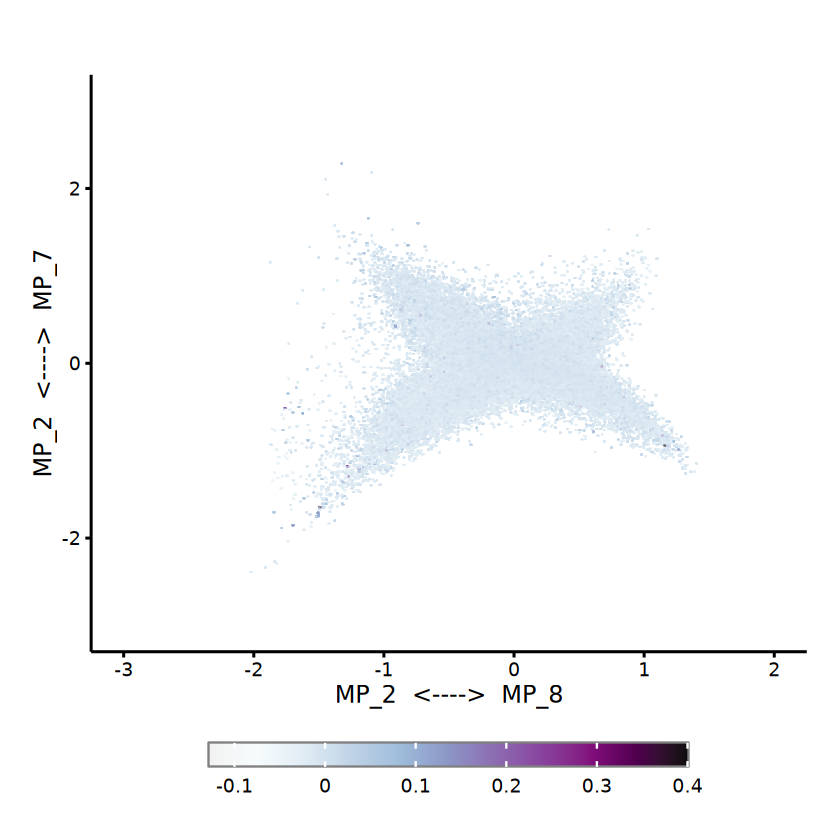

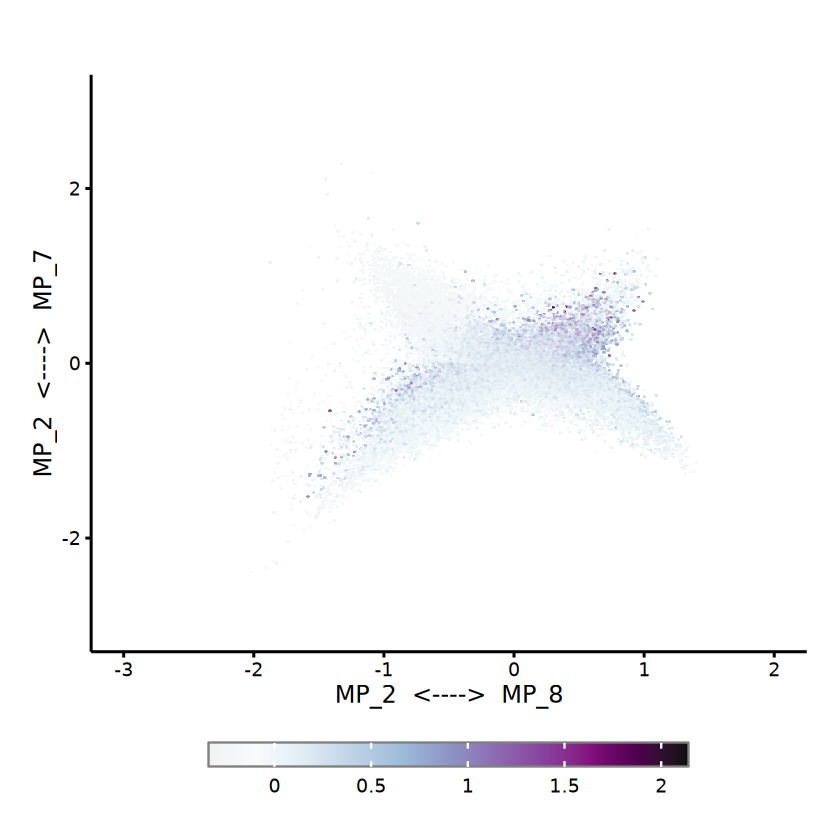

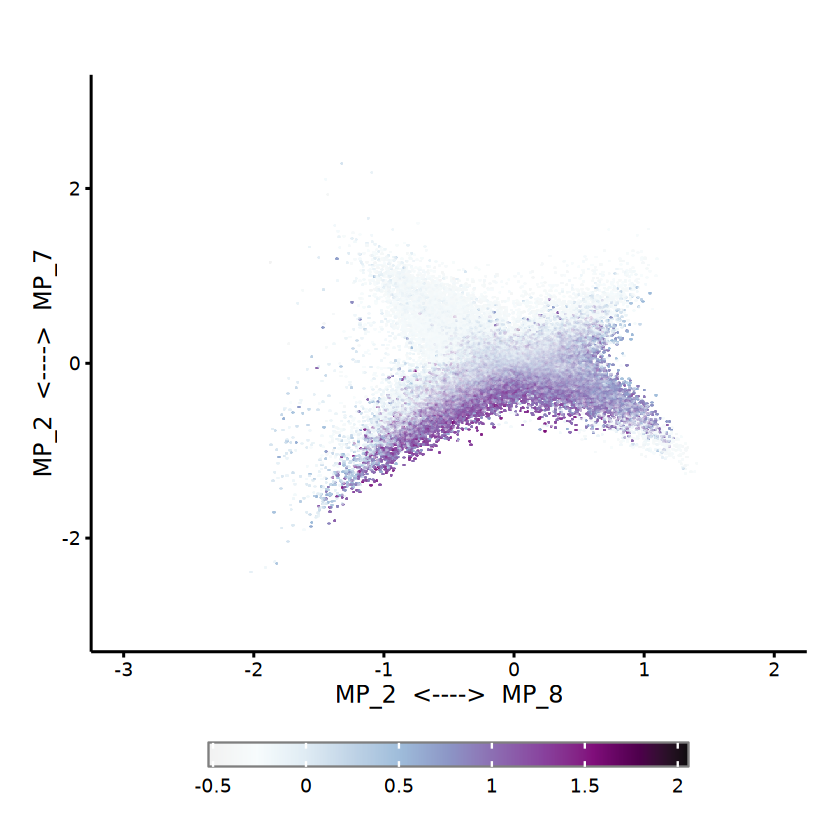

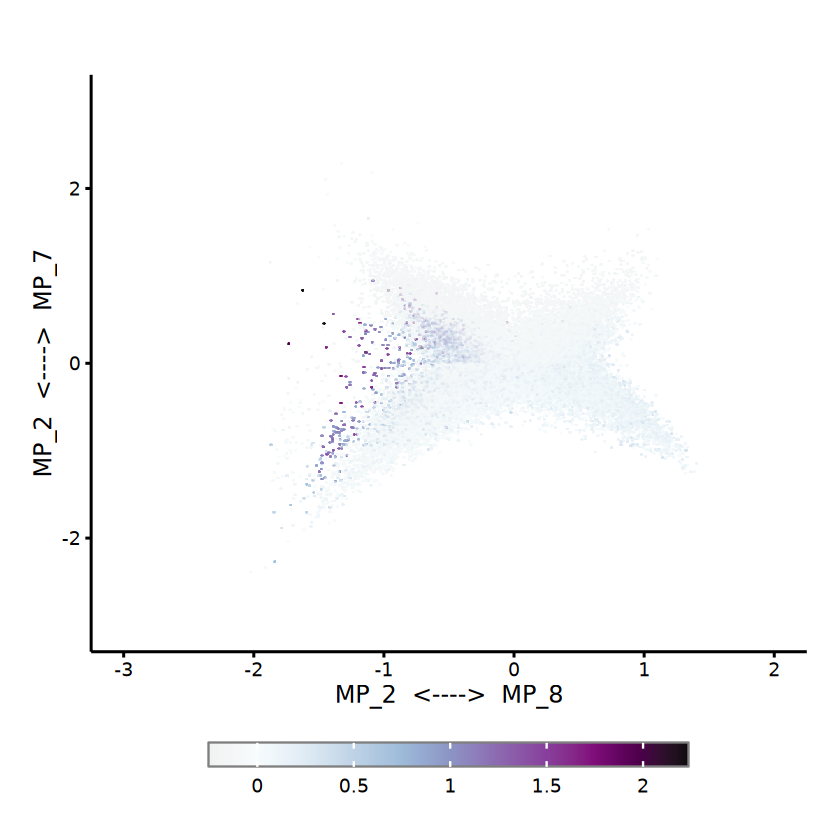

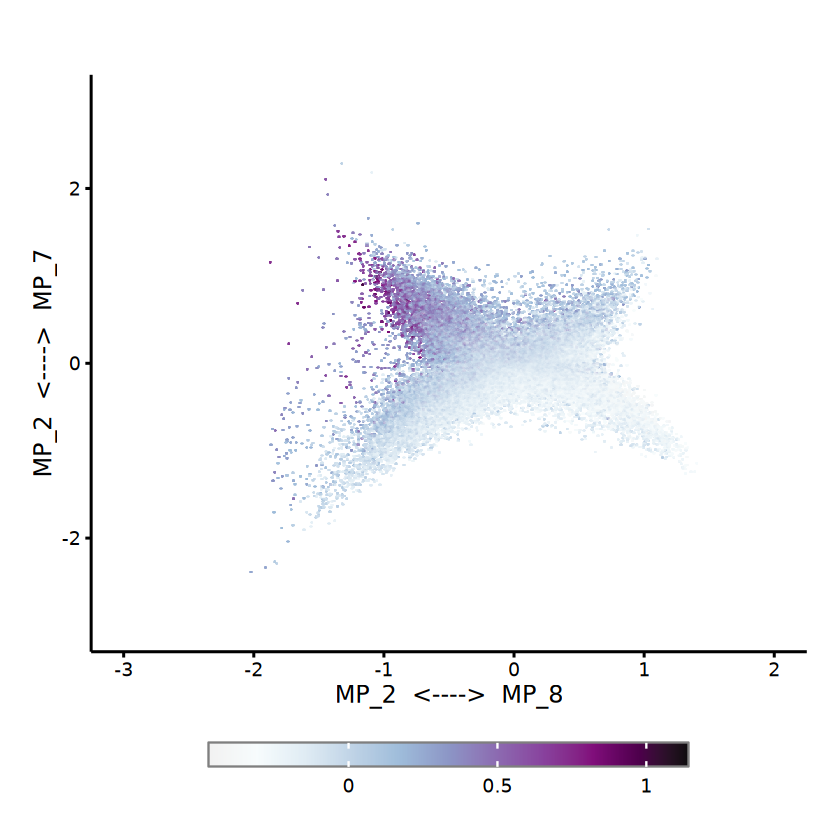

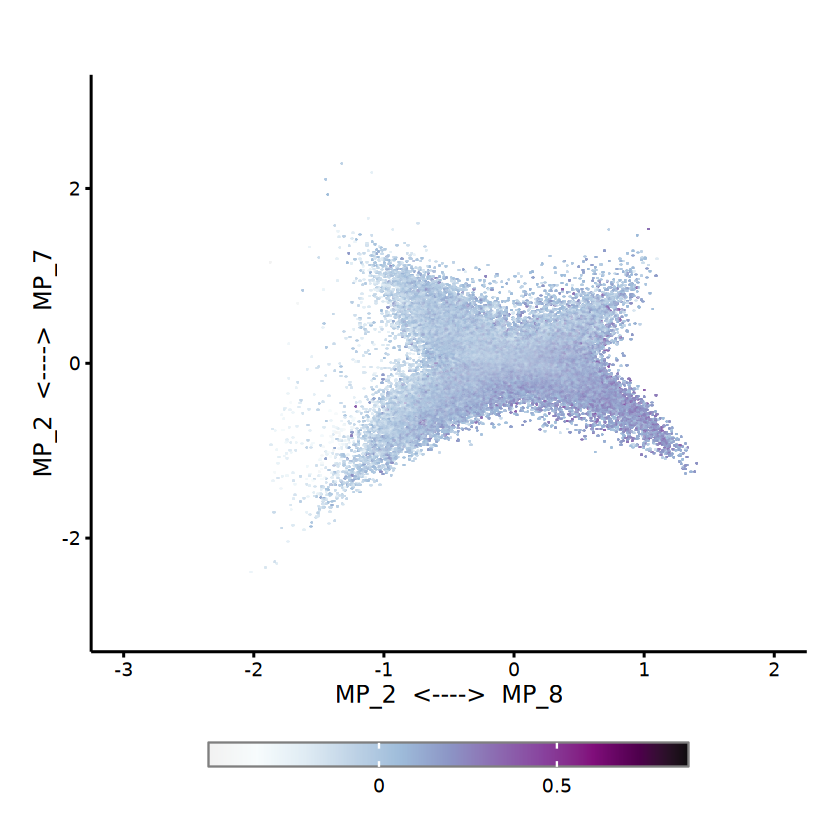

$MP_1_1

$MP_3_1

$MP_11_1

$MP_4_1

$MP_10_1

$MP_12_1

$BDM1

$main


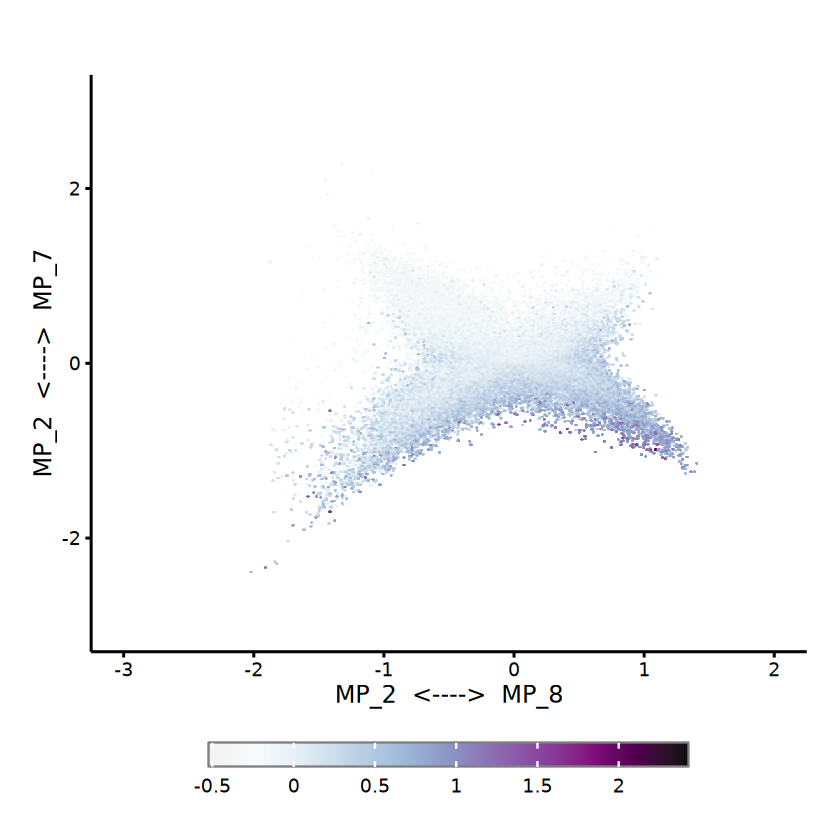

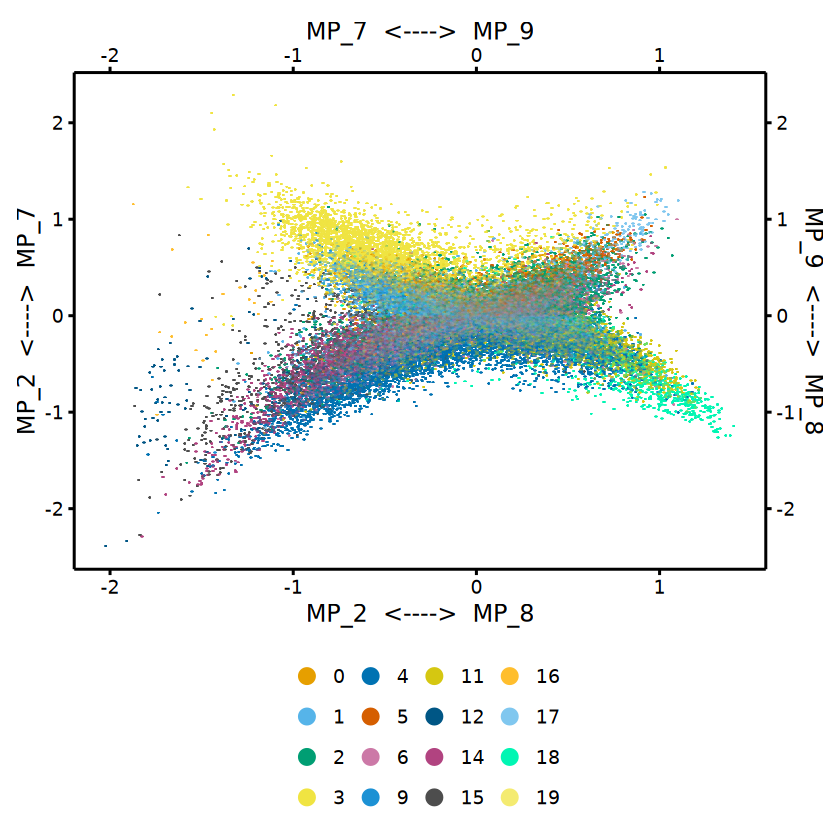

In [ ]:
options(repr.plot.height = 7, repr.plot.width = 7)
p <- do_CellularStatesPlot(sample = myeloid,
                      colors.use = colors_list,
                      group.by = 'leiden_1_3',
                      pt.size = 3,
                      plot_cell_borders = FALSE,
                      raster = TRUE,
                      # plot_marginal_distributions = TRUE,
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8",
                                   enforce_symmetry = FALSE,
                      use_viridis = FALSE,
                       sequential.palette='BuPu',
                      sequential.direction = 1,
                      plot_features = TRUE,
                     features = c("MP_1_1", "MP_3_1", "MP_11_1", "MP_4_1", "MP_10_1","MP_12_1",'BDM1')
                             )
p

In [ ]:
# Modified functions inspired from the source code of `do_CellularStatesPlot` to extract df for additional plotting in python

# Function to compute cell coordinates with log transformations for a 4-quadrant plot
# Now includes the 'flavor' option for computing enrichment scores
compute_CellCoordinates_LogTransform <- function(sample, input_gene_list, x1, y1, x2, y2, group.by = NULL, flavor = "Seurat") {
  # Define pipe operator internally if not already defined
  if (!exists("%>%")) {
    `%>%` <- magrittr::`%>%`
  }
  
  # Compute the enrichment scores with the specified 'flavor'
  sample <- compute_enrichment_scores(sample = sample, 
                                      input_gene_list = input_gene_list, 
                                      verbose = FALSE, 
                                      nbin = 24, 
                                      ctrl = 100, 
                                      flavor = flavor)
  
  # Setup for retrieving cell coordinates based on input parameters
  variables_to_retrieve <- unique(c(x1, y1, x2, y2, group.by))
  variables_to_retrieve <- variables_to_retrieve[!is.null(variables_to_retrieve)]
  
  # Retrieve metadata variables and ensure they are numeric
  cell_data <- sample@meta.data[, variables_to_retrieve, drop = FALSE]
  cell_data[["cell"]] <- rownames(cell_data)
  cell_data[, c(x1, x2, y1, y2)] <- lapply(cell_data[, c(x1, x2, y1, y2)], as.numeric)
  
  # Compute Y axis values using the provided logic
  y_values <- apply(cell_data[, c(x1, x2, y1, y2)], 1, function(x) {
    max_diff <- max(x[1], x[2], na.rm = TRUE) - max(x[3], x[4], na.rm = TRUE)
    return(max_diff)
  })
  
  # Compute X axis values using the provided logic
  x_values <- vapply(seq_along(y_values), function(i) {
    cell_row <- cell_data[i, ]
    if (y_values[i] > 0) {
      diff_val <- log2(abs(as.numeric(cell_row[x1]) - as.numeric(cell_row[x2])) + 1)
      return(ifelse(as.numeric(cell_row[x1]) < as.numeric(cell_row[x2]), -diff_val, diff_val))
    } else {
      diff_val <- log2(abs(as.numeric(cell_row[y1]) - as.numeric(cell_row[y2])) + 1)
      return(ifelse(as.numeric(cell_row[y1]) < as.numeric(cell_row[y2]), -diff_val, diff_val))
    }
  }, numeric(1))
  
  # Create a final dataframe to return, including computed log differences
  final_df <- data.frame(cell = cell_data[["cell"]],
                         x_log_difference = x_values,
                         y_log_difference = y_values,
                         stringsAsFactors = FALSE)
  
  # Include group.by information if provided
  if (!is.null(group.by) && group.by %in% names(cell_data)) {
    final_df[group.by] <- cell_data[[group.by]]
  }
  
  return(final_df)
}

In [ ]:
compute_enrichment_scores <- function(sample,
                                      input_gene_list,
                                      verbose = FALSE,
                                      nbin = 24,
                                      ctrl = 100,
                                      assay = NULL,
                                      slot = NULL,
                                      flavor = "Seurat",
                                      ncores = 16,
                                      storeRanks = TRUE,
                                      norm_data = FALSE){
  `%>%` <- magrittr::`%>%`


  if (!is.list(input_gene_list) & is.character(input_gene_list)){
    input_gene_list <- list("Input" = input_gene_list)
  }
  for (celltype in names(input_gene_list)){
    list_markers <- list(input_gene_list[[celltype]])

    if (flavor == "Seurat"){
      # Compute Seurat AddModuleScore as well.
      if (verbose){
        sample <- Seurat::AddModuleScore(sample,
                                         list_markers,
                                         name = celltype,
                                         search = TRUE,
                                         verbose = TRUE,
                                         nbin = nbin,
                                         ctrl = ctrl,
                                         assay = assay)
      } else {
        sample <- suppressMessages(suppressWarnings(Seurat::AddModuleScore(sample,
                                                                           list_markers,
                                                                           name = celltype,
                                                                           search = TRUE,
                                                                           verbose = FALSE,
                                                                           nbin = nbin,
                                                                           ctrl = ctrl,
                                                                           assay = assay)))
      }


      # Retrieve the scores.
      col_name <- stringr::str_replace_all(paste0(celltype, "1"), " ", ".")
      col_name <- stringr::str_replace_all(col_name, "-", ".")
      col_name <- stringr::str_replace_all(col_name, "\\+", ".")

      # Modify the name that Seurat::AddModuleScore gives by default.
      sample@meta.data[, celltype] <- sample@meta.data[, col_name]
      # Remove old metadata.
      sample@meta.data[, col_name] <- NULL
    }
  }
  if (flavor == "UCell"){
    list.names <- NULL
    for (celltype in names(input_gene_list)){
      col_name <- celltype
      col_name <- stringr::str_replace_all(col_name, "-", ">")
      col_name <- stringr::str_replace_all(col_name, " ", "_")
      col_name <- stringr::str_replace_all(col_name, "\\+", ".")
      list.names <- append(list.names, col_name)
    }
    list.originals <- names(input_gene_list)
    names(input_gene_list) <- list.names

    sample <- UCell::AddModuleScore_UCell(obj = sample,
                                          features = input_gene_list,
                                          assay = assay,
                                          slot = if (is.null(slot)){"data"} else {slot},
                                          name = "",
                                          ncores = ncores,
                                          storeRanks = storeRanks)

    for (i in seq_len(length(list.names))){
      old.name <- list.originals[i]
      mod.name <- list.names[i]
      # Modify the name that Seurat::AddModuleScore gives by default.
      sample@meta.data[, old.name] <- sample@meta.data[, mod.name]
      # Remove old metadata.
      if (old.name != mod.name){
        # nocov start
        sample@meta.data[, mod.name] <- NULL
        # nocov end
      }
    }
  }

  
  if (isTRUE(norm_data)){
    # Compute a 0-1 normalization.
    for (name in names(input_gene_list)){
      sample@meta.data[, name] <- zero_one_norm(sample@meta.data[, name])
    }
  }
  

  return(sample)
}

In [ ]:
for (i in 1:ncol(MP_list)) {
  gene_set <- as.data.frame(MP_list)[[i]]
  myeloid <- AddModuleScore(
    object = myeloid,
    features = list(gene_set),
    name = paste0(colnames(MP_list)[i], '_')
  )
}

Warning message:
“The following features are not present in the object: C12ORF57, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: C11ORF65, not searching for symbol synonyms”


In [ ]:
# Extracting the scores
scores <- FetchData(
  myeloid,
  vars = paste0("MP_", 1:ncol(MP_list), "_1")
)

In [ ]:
# Immunomodulatory programs
MP_list <- MP_list[, colnames(MP_list) %in% c("MP_2", "MP_7", "MP_8", "MP_9")]
MP_list

MP_2,MP_7,MP_8,MP_9
ACTG1,CCL3,F13A1,MYO1E
ATP5F1E,CD83,MRC1,GAS7
C1QC,NR4A1,COLEC12,GPNMB
CST3,CCL4,LYVE1,LPL
FAU,NR4A2,CD163,ASAP1
PTMA,CCL4L2,DAPK1,GLDN
CD63,EGR3,SELENOP,HIVEP1
FTL,IRAK2,THRB,MITF
S100A11,NFKBID,CD163L1,PTPRG
CD81,CCL3L1,MCTP1,RGCC


In [ ]:
df <- compute_CellCoordinates_LogTransform(sample = subset(myeloid_no_mg_homeostatic, Material == 'cell' | leiden_1_3 %in% c('8','10','7','13'), 
                                      invert=TRUE),
                                   input_gene_list = as.list(as.data.frame(MP_list)),
                                   x1 = "MP_7",
                                   y1 = "MP_2",
                                   x2 = "MP_9",
                                   y2 = "MP_8")

In [ ]:
df

,cell,x_log_difference,y_log_difference
,<chr>,<dbl>,<dbl>
BT042_PD_TGCGATAAGCCATCCG-1,BT042_PD_TGCGATAAGCCATCCG-1,0.42137851,-0.163040253
BT042_PD_GAATAGAGTTTATGCG-1,BT042_PD_GAATAGAGTTTATGCG-1,0.41447053,-0.439523439
BT042_PD_CCTGCATAGGTCACAG-1,BT042_PD_CCTGCATAGGTCACAG-1,0.19110417,0.159293517
BT042_PD_CGGAGAACAACTGCTA-1,BT042_PD_CGGAGAACAACTGCTA-1,-0.22520976,-0.164204462
BT042_PD_AGGGCTCCAACTCGTA-1,BT042_PD_AGGGCTCCAACTCGTA-1,0.23616420,0.001997831
BT042_PD_GAGGCCTCACAGACGA-1,BT042_PD_GAGGCCTCACAGACGA-1,-0.26681669,-0.085897518
BT042_PD_ACACTGACATAATCCG-1,BT042_PD_ACACTGACATAATCCG-1,0.31730853,-0.345210209
BT042_PD_TTCACGCTCGAGTGAG-1,BT042_PD_TTCACGCTCGAGTGAG-1,0.13597063,-0.126259024
BT042_PD_TGTGGCGTCTATACTC-1,BT042_PD_TGTGGCGTCTATACTC-1,0.24142229,0.059564808


In [ ]:
write.table(df %>% select(c(x_log_difference,y_log_difference)), file = 'data/quadrants_log_FINAL.txt', sep = "\t", quote = FALSE)

In [ ]:
scores <- scores[rownames(df),]

colnames(scores) <- sub("_1$", "", colnames(scores))
colnames(scores) <- sub("_", "", colnames(scores))

# exclude identity programs
dmg_mp <- scores %>% select(c('MP2', 'MP5', 'MP6', 'MP7','MP8','MP9','MP12'))
dmg_mp

,MP2,MP5,MP6,MP7,MP8,MP9,MP12
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BT042_PD_TGCGATAAGCCATCCG-1,0.03415157,-0.0065455401,-0.093559991,0.064428696,0.11490886,-0.072765798,0.07452140
BT042_PD_GAATAGAGTTTATGCG-1,0.18685520,-0.0442471115,-0.190025641,-0.073085107,0.26097250,-0.085841434,0.09258868
BT042_PD_CCTGCATAGGTCACAG-1,-0.45820713,-0.0001100043,-0.012646606,0.115023802,0.16574633,0.105209994,0.21418073
BT042_PD_CGGAGAACAACTGCTA-1,-0.15444584,-0.0271663028,-0.155796307,0.010894763,0.38456945,-0.042155165,0.02564366
BT042_PD_AGGGCTCCAACTCGTA-1,-0.26797151,-0.0285059217,-0.149259643,-0.028994205,0.17035060,-0.073958196,0.22934541
BT042_PD_GAGGCCTCACAGACGA-1,-0.28721043,-0.0429069517,-0.106979437,-0.014367484,0.27144924,-0.084445836,0.16164919
BT042_PD_ACACTGACATAATCCG-1,0.16793354,-0.0204222445,-0.036903802,-0.004028131,0.33054251,0.122673014,0.19296416
BT042_PD_TTCACGCTCGAGTGAG-1,0.08801238,-0.0133837862,-0.220606636,0.117037765,0.33531913,0.060785265,0.25305203
BT042_PD_TGTGGCGTCTATACTC-1,-0.53344863,-0.0262329718,-0.228840223,0.117435910,0.27435652,0.075622102,0.27483500


In [ ]:
write.table(dmg_mp, file = 'scores_myeloid_dmg_mp_FINAL.txt', sep = "\t", quote = FALSE)

### Python kernel

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Wedge
from matplotlib.collections import PatchCollection

# import glasbey

In [3]:
# Load the data from the files
scores_path = 'data/scores_myeloid_dmg_mp_FINAL.txt'
umap_path = 'data/quadrants_log_FINAL.txt'

scores_df = pd.read_csv(scores_path, sep='\t')
umap_df = pd.read_csv(umap_path, sep='\t')

# Display the first few rows of each dataframe for inspection
scores_df_head = scores_df.head()
umap_df_head = umap_df.head()

scores_df_head, umap_df_head

(                                  MP2       MP5       MP6       MP7       MP8  \
 BT042_PD_TGCGATAAGCCATCCG-1  0.034152 -0.006546 -0.093560  0.064429  0.114909   
 BT042_PD_GAATAGAGTTTATGCG-1  0.186855 -0.044247 -0.190026 -0.073085  0.260973   
 BT042_PD_CCTGCATAGGTCACAG-1 -0.458207 -0.000110 -0.012647  0.115024  0.165746   
 BT042_PD_CGGAGAACAACTGCTA-1 -0.154446 -0.027166 -0.155796  0.010895  0.384569   
 BT042_PD_AGGGCTCCAACTCGTA-1 -0.267972 -0.028506 -0.149260 -0.028994  0.170351   
 
                                   MP9      MP12  
 BT042_PD_TGCGATAAGCCATCCG-1 -0.072766  0.074521  
 BT042_PD_GAATAGAGTTTATGCG-1 -0.085841  0.092589  
 BT042_PD_CCTGCATAGGTCACAG-1  0.105210  0.214181  
 BT042_PD_CGGAGAACAACTGCTA-1 -0.042155  0.025644  
 BT042_PD_AGGGCTCCAACTCGTA-1 -0.073958  0.229345  ,
                              x_log_difference  y_log_difference
 BT042_PD_TGCGATAAGCCATCCG-1          0.421379         -0.163040
 BT042_PD_GAATAGAGTTTATGCG-1          0.414471         -0.439523
 BT0

In [4]:
import numpy as np

# Process the scores dataframe
# Identify cells with at least one positive score and their top 3 signatures
scores_df_processed = scores_df.apply(lambda x: x[x > 0].nlargest(3), axis=1)
scores_df_processed['sum_positive_scores'] = scores_df_processed.sum(axis=1)
scores_df_processed['is_unresolved'] = scores_df_processed['sum_positive_scores'] <= 0

# Normalize the top 3 scores for each cell
for col in scores_df_processed.columns[:-2]:  # excluding the last two columns we added
    scores_df_processed[col] = scores_df_processed[col] / scores_df_processed['sum_positive_scores']

# Merge UMAP coordinates with the processed scores
umap_scores_df = umap_df.join(scores_df_processed, how='left')

# Replace NaN with 0 for the pie chart representation
umap_scores_df.fillna(0, inplace=True)

# Display the first few rows of the merged dataframe
umap_scores_df.head()

,x_log_difference,y_log_difference,MP12,MP2,MP5,MP6,MP7,MP8,MP9,sum_positive_scores,is_unresolved
BT042_PD_TGCGATAAGCCATCCG-1,0.421379,-0.163040,0.293554,0.000000,0.0,0.0,0.253797,0.452648,0.0,0.253859,False
BT042_PD_GAATAGAGTTTATGCG-1,0.414471,-0.439523,0.171328,0.345762,0.0,0.0,0.000000,0.482910,0.0,0.540416,False
BT042_PD_CCTGCATAGGTCACAG-1,0.191104,0.159294,0.432731,0.000000,0.0,0.0,0.232394,0.334874,0.0,0.494951,False
BT042_PD_CGGAGAACAACTGCTA-1,-0.225210,-0.164204,0.060896,0.000000,0.0,0.0,0.025872,0.913233,0.0,0.421108,False
BT042_PD_AGGGCTCCAACTCGTA-1,0.236164,0.001998,0.573800,0.000000,0.0,0.0,0.000000,0.426200,0.0,0.399696,False


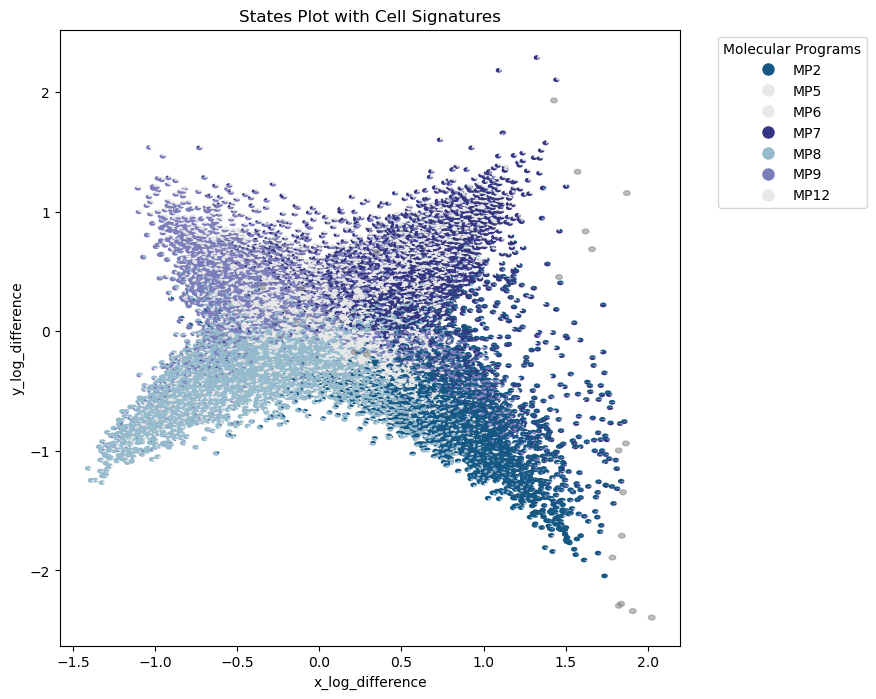

In [6]:
colors = ['#165884','#e8e8e8','#e8e8e8', '#343682', '#95bbcd','#7b7dba','#e8e8e8'] 

# Adjust the add_pie_to_plot function to handle color indexing
def add_pie_to_plot(ax, xy, sizes, colors):
    """Add a pie chart at a given location in the plot."""
    x, y = xy
    radius = 0.02  # Size of the pie chart
    wedges = []
    cum_size = 0

    for i, size in enumerate(sizes):
        if size > 0:
            start_angle = cum_size * 360
            end_angle = (cum_size + size) * 360
            color_index = i % len(colors)  # Cycle through colors if not enough
            wedge = Wedge(center=(x, y), r=radius, theta1=start_angle, theta2=end_angle, facecolor=colors[color_index])
            wedges.append(wedge)
            cum_size += size
    
    if wedges:
        p = PatchCollection(wedges, match_original=True)
        ax.add_collection(p)
    else:  # For unresolved cells
        circle = Circle((x, y), radius, color='gray', alpha=0.5)
        ax.add_patch(circle)

# Re-plot with adjusted color assignment
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x='x_log_difference', y='y_log_difference', data=umap_scores_df, alpha=0, ax=ax)

# Add pie charts to the plot
for index, row in umap_scores_df.iterrows():
    sizes = row[scores_df.columns].values  # The scores are used as sizes for the pie slices
    add_pie_to_plot(ax, (row['x_log_difference'], row['y_log_difference']), sizes, colors)

# Plot customization
ax.set_title('States Plot with Cell Signatures')
ax.set_xlabel('x_log_difference')
ax.set_ylabel('y_log_difference')

# # Create a custom legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=col, 
                              markersize=10, markerfacecolor=color) for col, color in zip(scores_df.columns, colors)]
ax.legend(handles=legend_elements, title="Molecular Programs", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.savefig('figures/state_plot_myeloid_FINAL.png',transparent=True,dpi=300)
plt.savefig('figures/state_plot_myeloid_FINAL.pdf')